In [19]:
!pip install graphviz

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv("insurance-2.csv")

print(df.head())
print(df.info())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [3]:
X = df.drop("charges", axis=1)
y = df["charges"]

num_features = ["age", "bmi", "children"]
cat_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer([
    ("num", RobustScaler(), num_features),
    ("cat", OneHotEncoder(drop="first"), cat_features)
])

X_processed = preprocessor.fit_transform(X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

# Basedline Model

In [5]:
baseline_model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
baseline_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [7]:
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 325469696.0000 - mae: 13518.6064 - val_loss: 310354048.0000 - val_mae: 12654.9863
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 325441312.0000 - mae: 13517.5723 - val_loss: 310319456.0000 - val_mae: 12653.6865
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 325384608.0000 - mae: 13515.5596 - val_loss: 310238464.0000 - val_mae: 12650.8115
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 325252064.0000 - mae: 13511.1797 - val_loss: 310065472.0000 - val_mae: 12644.8438
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 324979552.0000 - mae: 13502.3926 - val_loss: 309729376.0000 - val_mae: 12633.5498
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 324491392.0000 - mae: 13486.6504 - val_loss: 309153152.0000 - val_mae: 12614.4785
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 323702144.0000 - mae: 13461.6328 - val_loss: 308291488.0000 - val_mae: 12586.1807
Epoch 8/100


In [8]:
loss, mae = baseline_model.evaluate(X_test, y_test)

print("Baseline MAE:", mae)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 62291476.0000 - mae: 6130.3657
Baseline MAE: 6130.36572265625


In [9]:
y_pred = baseline_model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


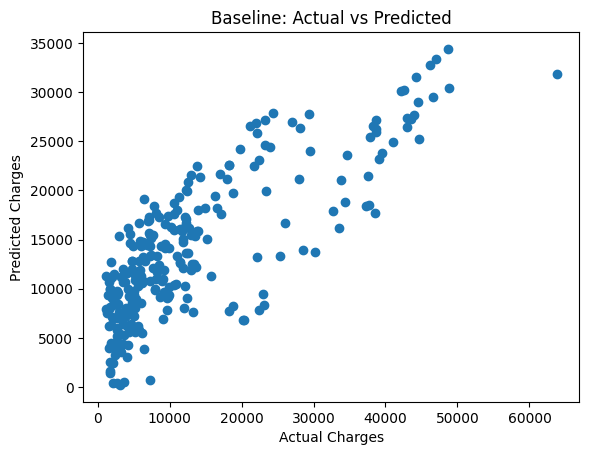

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Baseline: Actual vs Predicted")
plt.show()

# Compaer with other model

In [11]:
def build_model(input_dim):
    model = models.Sequential()

    model.add(layers.Dense(128, input_dim=input_dim))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(64))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.2))

    model.add(layers.Dense(32))
    model.add(layers.LeakyReLU())

    model.add(layers.Dense(1))  # regression output

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

#Initialize Model

In [12]:
model = build_model(X_train.shape[1])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 384 (1.50 KB)

#Plot Model Architecture

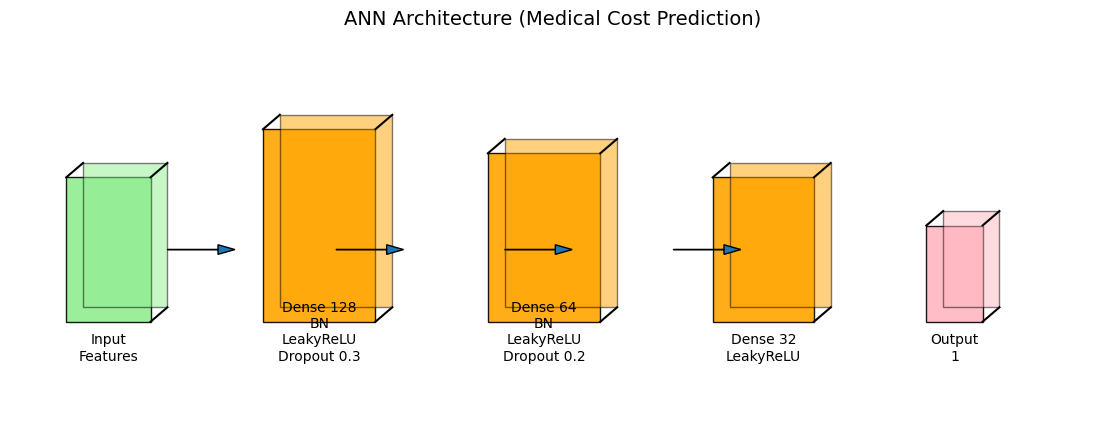

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def draw_3d_layer(ax, x, y, width, height, depth, color):
    # Front face
    front = Rectangle((x, y), width, height, facecolor=color, edgecolor='black', alpha=0.9)
    ax.add_patch(front)

    # Top face
    top = Rectangle((x + depth, y + depth), width, height,
                    facecolor=color, edgecolor='black', alpha=0.5)
    ax.add_patch(top)

    # Connect edges (3D effect)
    ax.plot([x, x + depth], [y + height, y + height + depth], 'k-')
    ax.plot([x + width, x + width + depth], [y + height, y + height + depth], 'k-')
    ax.plot([x + width, x + width + depth], [y, y + depth], 'k-')


def draw_model():
    fig, ax = plt.subplots(figsize=(14, 5))

    x = 0
    gap = 2

    layers = [
        ("Input\nFeatures", 1.5, 3, "lightgreen"),
        ("Dense 128\nBN\nLeakyReLU\nDropout 0.3", 2, 4, "orange"),
        ("Dense 64\nBN\nLeakyReLU\nDropout 0.2", 2, 3.5, "orange"),
        ("Dense 32\nLeakyReLU", 1.8, 3, "orange"),
        ("Output\n1", 1, 2, "lightpink")
    ]

    for name, w, h, color in layers:
        draw_3d_layer(ax, x, 0, w, h, 0.3, color)
        ax.text(x + w/2, -0.8, name, ha='center', fontsize=10)
        x += w + gap

    # Arrows
    for i in range(len(layers) - 1):
        ax.arrow(i*3 + 1.8, 1.5, 1.2, 0,
                 head_width=0.2, length_includes_head=True)

    ax.set_xlim(-1, x)
    ax.set_ylim(-2, 6)
    ax.axis('off')

    plt.title("ANN Architecture (Medical Cost Prediction)", fontsize=14)
    plt.show()


draw_model()

#Training + Tuning

In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - loss: 325410240.0000 - mae: 13517.3408 - val_loss: 310335136.0000 - val_mae: 12654.7549
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 325245792.0000 - mae: 13514.2754 - val_loss: 310232768.0000 - val_mae: 12652.6826
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 324907008.0000 - mae: 13509.5137 - val_loss: 309980032.0000 - val_mae: 12648.0811
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 324345728.0000 - mae: 13502.2725 - val_loss: 309551136.0000 - val_mae: 12640.5322
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 323550848.0000 - mae: 13491.5479 - val_loss: 308947264.0000 - val_mae: 12630.1572
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 322492960.0000 - mae: 13476.0000 - val_loss: 308183968.0000 - val_mae: 12618.2305
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 321208256.0000 - mae: 13456.1436 - val_loss: 307101760.0000 - val_mae: 12600.2373
Epoch 8/200

#Training Visualization

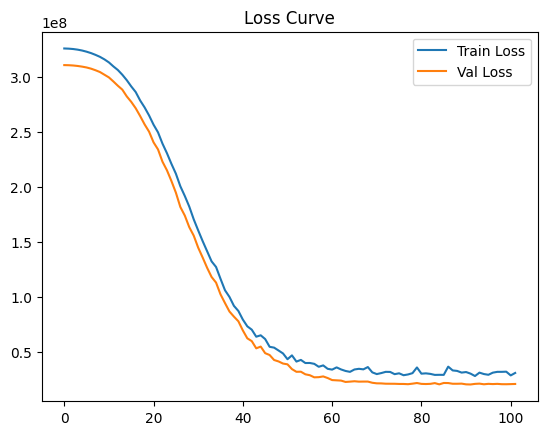

In [16]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

# Evaluation

In [17]:
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 19202794.0000 - mae: 2584.9963
Test MAE: 2584.996337890625


#Predictions vs Real

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


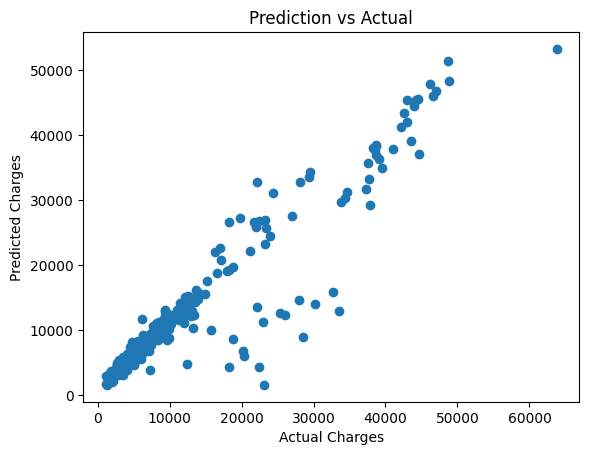

In [18]:
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Prediction vs Actual")
plt.show()